# Hugging Face Hub: API, Datasets & Inference (Live Class)

**Self-learning notebook** — comprehensive HF Hub exploration from live class (30 May 2026).

## What you will learn
- Use `HfApi` for model info, search, repo create/upload
- Load WikiText and Alpaca datasets; run `InferenceClient`
- Optional LangChain Hugging Face endpoint integration

## Prerequisites
- HF read + write tokens in Colab secrets

<a href="https://colab.research.google.com/github/mayankchugh-learning/Notebooks-FineTunLLM-Hugging-VectorDB-RAG/blob/main/Huggingface_Live_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata

In [ ]:
READ_TOKEN=userdata.get("HF_TOKEN_READ")

In [ ]:
WRITE_TOKEN=userdata.get('HF_TOKEN_WRITE')

In [ ]:
# import os
# os.environ["HF_READ_TOKEN"] = userdata.get("HF_READ_TOKEN")
# os.environ["HF_WRITE_TOKEN"] = userdata.get("HF_WRITE_TOKEN")

In [ ]:
# Setup: install dependencies for this section (run once per session)
!pip install --upgrade huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 18.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0


In [ ]:
# from huggingface_hub import login
# login(READ_TOKEN)
# login(WRITE_TOKEN)

In [ ]:
from huggingface_hub import HfApi
# api = HfApi(token=WRITE_TOKEN)
api = HfApi()

In [ ]:
# api.create_repo(
#     repo_id="sunny199/sunnyrepo",  # full path
#     repo_type="model",                         # or just skip (default is model)
#     private=False                              # set True for private repo
# )

In [ ]:
# api.upload_file(
#     path_or_fileobj="/content/testfile/config.json",
#     path_in_repo="config.json",  # Where it goes in repo
#     repo_id="sunny199/sunnyrepo"  # Same as created above
# )

In [ ]:
# Get model info without downloading it
model_info = api.model_info(repo_id="bert-base-uncased")

In [ ]:
print("Model Card Metadata:", model_info.card_data)
print("Tags:", model_info.tags)
print("Commit SHA:", model_info.sha)
print("Last Modified:", model_info.last_modified)
print("Files:", [f.rfilename for f in model_info.siblings])
print("Model ID:", model_info.card_data.get('modelId', 'Not available'))
print("Likes:", model_info.likes)
print("Author/Namespace:", model_info.author)
print("Is Private:", model_info.private)
print("Downloads:", model_info.downloads)

Model Card Metadata: datasets:
- bookcorpus
- wikipedia
language: en
license: apache-2.0
tags:
- exbert
Tags: ['transformers', 'pytorch', 'tf', 'jax', 'rust', 'coreml', 'onnx', 'safetensors', 'bert', 'fill-mask', 'exbert', 'en', 'dataset:bookcorpus', 'dataset:wikipedia', 'arxiv:1810.04805', 'license:apache-2.0', 'endpoints_compatible', 'deploy:azure', 'region:us']
Commit SHA: 86b5e0934494bd15c9632b12f734a8a67f723594
Last Modified: 2024-02-19 11:06:12+00:00
Files: ['.gitattributes', 'LICENSE', 'README.md', 'config.json', 'coreml/fill-mask/float32_model.mlpackage/Data/com.apple.CoreML/model.mlmodel', 'coreml/fill-mask/float32_model.mlpackage/Data/com.apple.CoreML/weights/weight.bin', 'coreml/fill-mask/float32_model.mlpackage/Manifest.json', 'flax_model.msgpack', 'model.onnx', 'model.safetensors', 'pytorch_model.bin', 'rust_model.ot', 'tf_model.h5', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']
Model ID: Not available
Likes: 2661
Author/Namespace: google-bert
Is Private: False
D

In [ ]:
models = api.list_models(search="llama",limit=50)

In [ ]:
models

<generator object HfApi.list_models at 0x7f17a076f680>

In [ ]:
for model in models:
    print(model.modelId, "-", model.downloads)

meta-llama/Llama-3.1-8B-Instruct - 10578535
NousResearch/Hermes-3-Llama-3.1-8B - 221708
aifeifei798/llama3-8B-DarkIdol-2.3-Uncensored-32K - 1294
meta-llama/Llama-3.2-1B-Instruct - 8056945
meta-llama/Llama-3.2-1B - 2033091
meta-llama/Meta-Llama-3-8B-Instruct - 1671206
meta-llama/Llama-3.2-3B-Instruct - 2090260
meta-llama/Llama-3.1-8B - 1252436
meta-llama/Llama-3.3-70B-Instruct - 951361
meta-llama/Meta-Llama-3-8B - 2369660
meta-llama/Llama-3.2-3B - 1155024
DavidAU/Llama-3.2-8X3B-MOE-Dark-Champion-Instruct-uncensored-abliterated-18.4B-GGUF - 50752
meta-llama/Llama-Prompt-Guard-2-86M - 153100
meta-llama/Llama-2-7b-chat-hf - 355651
meta-llama/Prompt-Guard-86M - 1322812
meta-llama/Llama-4-Scout-17B-16E-Instruct - 409477
meta-llama/Llama-Guard-3-8B - 83719
bartowski/Llama-3.2-3B-Instruct-GGUF - 293258
bartowski/LLaMA-Mesh-GGUF - 4468
nvidia/llama-nemotron-embed-vl-1b-v2 - 145539
nvidia/llama-nemotron-rerank-vl-1b-v2 - 123743
SuperPeaceBusters/Menma-LLaMA3.2-1B-v1 - 86
meta-llama/Llama-2-7b - 

In [ ]:
models = api.list_models(search="embedding",limit=50)

In [ ]:
for model in models:
    print(model.modelId, "-", model.downloads)

jinaai/jina-embeddings-v5-omni-small - 35994
Qwen/Qwen3-Embedding-0.6B - 6974724
google/embeddinggemma-300m - 1945402
Qwen/Qwen3-VL-Embedding-8B - 939757
Qwen/Qwen3-VL-Embedding-2B - 1355428
ibm-granite/granite-embedding-97m-multilingual-r2 - 41186
ibm-granite/granite-embedding-311m-multilingual-r2 - 72912
Qwen/Qwen3-Embedding-8B - 1616414
zeroentropy/zembed-1-embedding - 318296
jinaai/jina-embeddings-v4 - 570194
jinaai/jina-embeddings-v5-text-nano - 280074
jinaai/jina-embeddings-v5-text-small - 244614
Ill-Ness/Silas-Embedding - 41
Octen/Octen-Embedding-8B - 45176
jinaai/jina-embeddings-v5-omni-nano - 86133
BidirLM/BidirLM-Omni-2.5B-Embedding - 8166
Qwen/Qwen3-Embedding-8B-GGUF - 24904
Qwen/Qwen3-Embedding-0.6B-GGUF - 37340
litert-community/embeddinggemma-300m - 1953
unsloth/embeddinggemma-300m-GGUF - 11868
KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5 - 6624
jinaai/jina-embeddings-v5-omni-small-retrieval - 34739
geevec-ai/geevec-embeddings-1.0 - 0
drawais/Qwen3-Embeddi

In [ ]:
from huggingface_hub import list_repo_files
files = list_repo_files("google/flan-t5-base")
print(files)

['.gitattributes', 'README.md', 'config.json', 'flax_model.msgpack', 'generation_config.json', 'model.safetensors', 'pytorch_model.bin', 'special_tokens_map.json', 'spiece.model', 'tf_model.h5', 'tokenizer.json', 'tokenizer_config.json']


In [ ]:
dataset = api.dataset_info("imdb")
print("Files:", [f.rfilename for f in dataset.siblings])

Files: ['.gitattributes', 'README.md', 'plain_text/test-00000-of-00001.parquet', 'plain_text/train-00000-of-00001.parquet', 'plain_text/unsupervised-00000-of-00001.parquet']


In [ ]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    model="Qwen/Qwen2.5-7B-Instruct"
)
response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": "Explain Hugging Face in simple words"}
    ],
    max_tokens=200
)
print(response.choices[0].message.content)

Sure! Hugging Face is a company and a community that focuses on natural language processing (NLP), which is a part of artificial intelligence that deals with how computers understand and generate human language. Here are some simple points to understand Hugging Face:

1. **Platform for NLP**: Hugging Face provides a platform where researchers, developers, and data scientists can work on NLP tasks. It's like a playground for building and experimenting with language models.

2. **Models and Libraries**: They offer a wide range of pre-trained language models, which are like pre-built tools that can understand and generate text. These models are based on deep learning techniques and are designed to perform various NLP tasks.

3. **Transformers**: Hugging Face is particularly known for its work with transformers, a type of neural network architecture that has revolutionized NLP. They provide easy-to-use libraries and tools to work with these models.

4. **Community and Resources**: The comp

In [ ]:
# !pip install accelerate
# !pip install  bitsandbytes
!pip install langchain-huggingface
!pip install langchain_community

In [ ]:
from langchain_huggingface import ChatHuggingFace
from langchain_huggingface import HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
)
chat_model = ChatHuggingFace(llm=llm)
chat_model.invoke("hello how are you?")

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

template="""Question: {question}
give me a answer in detail manner and in step by step manner"""

prompt=PromptTemplate(template=template,input_variables=["question"])

llm_chain = (
        {"question": RunnablePassthrough()}
        | prompt
        | chat_model
        | StrOutputParser()
    )

question="who is a first president of INDIA?"

llm_chain.invoke({"question":question})

"\n### Step-by-Step Answer: Who is the first president of India?\n\n#### **Step 1: Understanding the Context**\n- India became an independent nation on **August 15, 1947**, but remained a British Dominion under the Governor-General (like Lord Mountbatten and later C. Rajagopalachari).\n- On **January 26, 1950**, India adopted its Constitution and became a **sovereign democratic republic**. This date marked the creation of the office of the President of India.\n\n#### **Step 2: The Role of the President**\n- The President of India is the **constitutional head of state**, commander-in-chief of the armed forces, and the first citizen of India.\n- The position was established to replace the Governor-General after India transitioned to a republic.\n\n#### **Step 3: Identifying the First President**\n- The first President of India was **Dr. Rajendra Prasad**.\n- He was elected unopposed by the **Constituent Assembly of India** (which doubled as the provisional parliament) on **January 24, 19

### 30-may-2026

read_token--> we can read anything from hf
write_token--> if we want to upload anything over the hf then we will use write

git--> github
hf-->hf hub(models, dataset)
hf repo
docker--> docker hub
ollama--> ollama hub

In [ ]:
import os
from huggingface_hub import HfApi
from google.colab import userdata

In [ ]:
api = HfApi(token=WRITE_TOKEN)

In [ ]:
api.create_repo(
    repo_id="sunny199/mytestingrepoformodel",  # full path
    repo_type="model",                         # or just skip (default is model)
    private=False                              # set True for private repo
)

RepoUrl('https://huggingface.co/sunny199/mytestingrepoformodel', endpoint='https://huggingface.co', repo_type='model', repo_id='sunny199/mytestingrepoformodel')

In [ ]:
api.upload_file(
    path_or_fileobj="/content/test_file/dataset_info.json",
    path_in_repo="dataset_info.json",  # Where it goes in repo
    repo_id="sunny199/mytestingrepoformodel"  # Same as created above
)

CommitInfo(commit_url='https://huggingface.co/sunny199/mytestingrepoformodel/commit/a7efdf9f80aad366548e7880566c712cf07576ea', commit_message='Upload dataset_info.json with huggingface_hub', commit_description='', oid='a7efdf9f80aad366548e7880566c712cf07576ea', pr_url=None, repo_url=RepoUrl('https://huggingface.co/sunny199/mytestingrepoformodel', endpoint='https://huggingface.co', repo_type='model', repo_id='sunny199/mytestingrepoformodel'), pr_revision=None, pr_num=None)

## Notebook login

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
## Install datasets library

file system specification library

In [ ]:
!pip install -U datasets fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


| Config                |  Size | Text type | Use                |
| --------------------- | ----: | --------- | ------------------ |
| `wikitext-2-raw-v1`   | Small | Raw       | Learning/demo      |
| `wikitext-2-v1`       | Small | Processed | Benchmark/old NLP  |
| `wikitext-103-raw-v1` | Large | Raw       | Better LM training |
| `wikitext-103-v1`     | Large | Processed | Benchmark/old NLP  |


In [ ]:
from datasets import load_dataset

In [ ]:
pretrain_dataset = load_dataset(
    "Salesforce/wikitext",      # dataset repo / dataset name
    "wikitext-2-raw-v1",        # dataset variant / config
    split="train"               # train/validation/test part
)

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [ ]:
print(pretrain_dataset)

Dataset({
    features: ['text'],
    num_rows: 36718
})


In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(pretrain_dataset[i])
    print("-" * 50)

Row 0:
{'text': ''}
--------------------------------------------------
Row 1:
{'text': ' = Valkyria Chronicles III = \n'}
--------------------------------------------------
Row 2:
{'text': ''}
--------------------------------------------------
Row 3:
{'text': ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n'}
-----------------------------

In [ ]:
## example of instruction ft dataset or SFT dataset
sft_dataset = load_dataset(
    "tatsu-lab/alpaca",
    split="train"
)

README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

In [ ]:
print(sft_dataset)

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 52002
})


In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(sft_dataset[i])
    print("-" * 50)

Row 0:
{'instruction': 'Give three tips for staying healthy.', 'input': '', 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}
--------------------------------------------------
Row 1:
{'instruction': 'What are the three primary colors?', 'input': '', 'output': 'The three primary colors are red, blue, and yellow.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n

In [ ]:
preference_dataset = load_dataset(
    "Anthropic/hh-rlhf",
    split="train"
)

README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

helpful-rejection-sampled/train.jsonl.gz:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

...

helpful-base/test.jsonl.gz:   0%|          | 0.00/875k [00:00<?, ?B/s]

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

In [ ]:
print(preference_dataset)

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 160800
})


In [ ]:
for i in range(15):
    print(f"Row {i}:")
    print(preference_dataset[i])
    print("-" * 50)

Row 0:
{'chosen': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, jizz, jizz-licking, prostitute, slut, cheater, fornicator, floozy, wetback, Mexican, Hispanic, sodomite, midget, mama’s boy, faggot, pervert, queer, scumbag, bitch,\n\nHuman: What's your favorite one?\n\nAssistant: I haven't even thought about it.", 'rejected': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, ji

In [ ]:
dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"])

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, even then it\'s not shot like some cheaply made porno. While my countrymen mind find it shocking, in reality sex and nudity are a major staple in Swedish cinema. Even Ingmar Bergman, arguably their answer to good old boy John Ford, had sex scenes in his films.<br /><br />I do commend the filmmakers for the fact that any sex shown in the film is shown for artistic purposes rather than just to shock people and make money to be shown in pornographic theaters in America. I AM CURIOUS-YELLOW is a good film for anyone wanting to study the meat and potatoes (no pun intended) of Swedish cinema. But really, this film doesn\'t have much of a plot.', 'label': 0}

In [ ]:
print(dataset["train"].features)
print(dataset["train"].column_names)
print(dataset["train"].features["label"].names)
print(dataset["train"].num_rows)
print(dataset["train"].num_columns)
print(dataset["train"].shape)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}
['text', 'label']
['neg', 'pos']
25000
2
(25000, 2)


In [ ]:
shuffled = dataset["train"].shuffle()

In [ ]:
shuffled

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [ ]:
shuffled = dataset["train"].shuffle(seed=42)

In [ ]:
subset_train = dataset["train"].shuffle().select(range(5000))

In [ ]:
subset_train

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})

In [ ]:
dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [ ]:
short_reviews = dataset["train"].filter(lambda x: len(x["text"]) < 100)

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
short_reviews

Dataset({
    features: ['text', 'label'],
    num_rows: 9
})

In [ ]:
short_positive = dataset["train"].filter(lambda x: x["label"] == 1 and len(x["text"]) < 200)

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
short_positive

Dataset({
    features: ['text', 'label'],
    num_rows: 60
})

In [ ]:
def add_word_count(example):
    example["word_count"] = len(example["text"].split())
    return example

In [ ]:
dataset = dataset.map(add_word_count)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'word_count'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'word_count'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'word_count'],
        num_rows: 50000
    })
})

In [ ]:
print(dataset["train"][0]["word_count"])

288


streaming=True Parameter

Normally, Hugging Face datasets are downloaded completely to disk before being used (especially for large datasets, this can be slow/heavy).

When streaming=True:

The dataset is not downloaded in full

Data is streamed sample-by-sample on-the-fly

Useful for huge datasets that can’t fit into memory (like c4, the_pile, openwebtext)

You get a generator-style iterable dataset, not an in-memory list

Dataset: openwebtext

Size: ~8.13 million documents

Total tokens: ~40+ billion tokens

Size on disk: ~38 GB

In [ ]:
big_data = load_dataset(
    "Skylion007/openwebtext",
    streaming=True
)

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

### metadata (80 shards/files)

In [ ]:
big_data

IterableDatasetDict({
    train: IterableDataset({
        features: ['text'],
        num_shards: 80
    })
})

In [ ]:
for i, row in enumerate(big_data["train"]):
    print(row)
    print("-" * 50)

    if i == 14:
        break

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t

In [ ]:
print(row["text"][:500])

Get cool in-game extras with amiibo accessories! Just tap to score new characters, game modes, or other perks.

One amiibo may work with multiple games. You might get new outfits, power-ups, or other fun bonuses.

Link is the main character in The Legend of Zelda games. A young boy living in Hyrule, Link is often given the task of rescuing Princess Zelda and Hyrule from the Gerudo thief Ganondorf. Humble to the end, Link is known not merely as a hero but as a symbol of courage, strength and wisd


In [ ]:
for item in big_data["train"].take(5):
    print(item)

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t

## Custom dataset

In [ ]:
from datasets import Dataset

In [ ]:
import pandas as pd
data = {
    "text": [
        "I love this product! Works great ",
        "Terrible experience, I want a refund.",
        "Fast delivery and excellent packaging.",
        "Worst app I’ve ever used. Crashed in 1 minute.",
        "Super helpful support team, thanks a lot!",
        "Nothing worked. Waste of time."
    ],
    "label": [1, 0, 1, 0, 1, 0]  # 1 = Positive, 0 = Negative
}

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df

,text,label
0,I love this product! Works great,1
1,"Terrible experience, I want a refund.",0
2,Fast delivery and excellent packaging.,1
3,Worst app I’ve ever used. Crashed in 1 minute.,0
4,"Super helpful support team, thanks a lot!",1
5,Nothing worked. Waste of time.,0


In [ ]:
dataset = Dataset.from_pandas(df)

In [ ]:
dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 6
})

In [ ]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN_WRITE")

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '6570208f15709277ede7d985', 'name': 'sunny199', 'fullname': 'sunny savita', 'email': 'engsunny3365@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1780272000, 'isPro': False, 'avatarUrl': '/avatars/dfb8ae1e662d7a9995b3059127282976.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'testinglivewrite', 'role': 'write', 'createdAt': '2025-06-24T19:33:21.245Z'}}}


{'type': 'user', 'id': '6570208f15709277ede7d985', 'name': 'sunny199', 'fullname': 'sunny savita', 'email': 'engsunny3365@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1780272000, 'isPro': False, 'avatarUrl': '/avatars/dfb8ae1e662d7a9995b3059127282976.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'testinglivewrite', 'role': 'write', 'createdAt': '2025-06-24T19:33:21.245Z'}}}

In [ ]:
dataset.push_to_hub("sunny199/mycustomdatalivebootcamp")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmpl_a658d3.parquet    : 100%|##########| 1.66kB / 1.66kB            

CommitInfo(commit_url='https://huggingface.co/datasets/sunny199/mycustomdatalivebootcamp/commit/bb6a520c869cc7ce243ea42c61e4d3a8a4acd668', commit_message='Upload dataset', commit_description='', oid='bb6a520c869cc7ce243ea42c61e4d3a8a4acd668', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sunny199/mycustomdatalivebootcamp', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sunny199/mycustomdatalivebootcamp'), pr_revision=None, pr_num=None)

In [ ]:
from datasets import Dataset

data = {
    "instruction": [
        "Translate English to Hindi",
        "Summarize the text",
        "Explain Machine Learning"
    ],
    "input": [
        "I love India",
        "Artificial Intelligence is transforming industries.",
        ""
    ],
    "output": [
        "मुझे भारत पसंद है",
        "AI industries ko transform kar raha hai.",
        "Machine Learning is a subset of AI."
    ]
}

dataset = Dataset.from_dict(data)

In [ ]:
dataset

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 3
})

### Tokenization

"I love AI"

["I", "love", "AI"]

[40, 1842, 9552]



| Model   | Tokenizer Type   |
| ------- | ---------------- |
| BERT    | WordPiece        |
| GPT-2   | BPE              |
| Llama   | SentencePiece    |
| T5      | SentencePiece    |
| Qwen    | custom tokenizer |
| Mistral | SentencePiece    |


In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer

In [ ]:
# from transformers import AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
text = "I love AI"

In [ ]:
output = tokenizer(text)

In [ ]:
print(output)

{'input_ids': [101, 146, 1567, 19016, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(output["input_ids"])

'input_ids': [101, 146, 1567, 19016, 102]

In [ ]:
print(tokens)

['[CLS]', 'I', 'love', 'AI', '[SEP]']


In [ ]:
output = tokenizer("I love AI", "I love ML")

In [ ]:
print(output)

{'input_ids': [101, 146, 1567, 19016, 102, 146, 1567, 150, 2162, 102], 'token_type_ids': [0, 0, 0, 0, 0, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
tokenizers = [
    "bert-base-uncased",
    "bert-base-cased",
    "roberta-base",
    "distilbert-base-uncased",
    "gpt2",
    "facebook/opt-125m",
    "google/flan-t5-small",
    "t5-small",
    "microsoft/deberta-v3-base",
    "xlnet-base-cased",
    "albert-base-v2",
    "sentence-transformers/all-MiniLM-L6-v2",
    "meta-llama/Llama-2-7b-hf",
    "mistralai/Mistral-7B-v0.1",
    "Qwen/Qwen2.5-0.5B",
    "google/gemma-2-2b",
]

In [ ]:
for model_name in tokenizers:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(model_name, "->", tokenizer.__class__.__name__)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

bert-base-uncased -> BertTokenizer
bert-base-cased -> BertTokenizer


...

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

google/gemma-2-2b -> GemmaTokenizer


In [ ]:
hindi_tokenizer = AutoTokenizer.from_pretrained("ai4bharat/indic-bert")

config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

In [ ]:
tokens=hindi_tokenizer.tokenize("मुझे एआई पसंद है।")

In [ ]:
tokens

['▁', 'मझ', '▁एआई', '▁प', 'सद', '▁ह', '।']

1. input_ids:

These are the IDs of the tokens from the model’s vocabulary.

The sentence "Hello, how are you?" gets tokenized as:

[CLS] Hello , how are you ? [SEP]

Which corresponds to:

[101, 7592, 1010, 2129, 2024, 2017, 1029, 102]

2. token_type_ids:

These are used in tasks like Next Sentence Prediction.

0 means it's part of the first sentence

If there was a second sentence, it would have 1s

Since your input is just a single sentence, all values are 0.

3. attention_mask:

Tells the model which tokens are real and which are padding.

1 means the token is real (not padding)

0 means it’s padding (none here)

What does return_tensors="pt" do?

It returns everything as PyTorch tensors (pt = PyTorch).

If you use return_tensors="tf", you'll get TensorFlow tensors.

BPE-
wordpiece-google
sentence_piece-google


# Custom Tokenizer Training Pipeline

```text
Raw Text Corpus
      ↓
Train BPE Tokenizer
      ↓
Save tokenizer.json
      ↓
Convert to Hugging Face Tokenizer
      ↓
Save my_tokenizer_hf Folder
```

BPE = Byte Pair Encoding.

Simple idea:

Frequently appearing characters/subwords ko merge karke vocabulary banata hai.

Example:

t + r → tr

tr + a → tra

tra + n → tran

...

transformers

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [ ]:
corpus = ["I love transformers!",
          "Tokenizers are amazing.",
          "Build your own.\n"]

In [ ]:
corpus


['I love transformers!', 'Tokenizers are amazing.', 'Build your own.\n']

In [ ]:
tokenizer = Tokenizer(models.BPE())

In [ ]:
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

In [ ]:
trainer = trainers.BpeTrainer(vocab_size=100)

In [ ]:
tokenizer.train_from_iterator(corpus, trainer)

In [ ]:
tokenizer.save("custom-tokenizer.json")

In [ ]:
from transformers import PreTrainedTokenizerFast

In [ ]:
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="/content/custom-tokenizer.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

In [ ]:
hf_tokenizer.save_pretrained("my_tokenizer_hf")

('my_tokenizer_hf/tokenizer_config.json', 'my_tokenizer_hf/tokenizer.json')

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("my_tokenizer_hf")

In [ ]:
text = "I love transformers!"

output = tokenizer(text)

print(output)

{'input_ids': [3, 54, 57, 0], 'attention_mask': [1, 1, 1, 1]}


| Feature                       | BPE (Byte Pair Encoding)                                 | WordPiece                                             | SentencePiece                             |
| ----------------------------- | -------------------------------------------------------- | ----------------------------------------------------- | ----------------------------------------- |
| **Developed By**              | Originally for compression, later used in GPT models     | Google (BERT)                                         | Google                                    |
| **Used In**                   | GPT-2, RoBERTa, LLaMA (variants)                         | BERT, DistilBERT                                      | T5, ALBERT, mT5, LLaMA tokenizer training |
| **Training Strategy**         | Merge most frequent character pairs repeatedly           | Choose merge that maximizes language model likelihood | Learns subwords directly from raw text    |
| **Input Requirement**         | Requires pre-tokenized text (spaces already split words) | Requires pre-tokenized text                           | Works directly on raw text                |
| **Space Handling**            | Spaces are separators                                    | Spaces are separators                                 | Treats space as a normal symbol (`▁`)     |
| **Merge Selection**           | Frequency-based                                          | Probability/Likelihood-based                          | Unigram Language Model or BPE             |
| **Vocabulary Creation**       | Frequent character pair merges                           | Best likelihood improvement merges                    | Probabilistic subword selection           |
| **Unknown Words**             | Split into smaller subwords                              | Split into smaller subwords                           | Split into smaller subwords               |
| **Language Independence**     | Moderate                                                 | Moderate                                              | Very high                                 |
| **Best For**                  | Simple and fast tokenization                             | Better linguistic segmentation                        | Multilingual and production systems       |
| **Training Complexity**       | Low                                                      | Medium                                                | Higher                                    |
| **Token Example ("playing")** | play + ing                                               | play + ##ing                                          | ▁play + ing                               |
| **Special Marker**            | None                                                     | `##` for continuation                                 | `▁` for word boundary                     |


### Now load the models

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
inputs = tokenizer("Hello, how are you?", return_tensors="pt")

In [ ]:
inputs

{'input_ids': tensor([[ 101, 8667,  117, 1293, 1132, 1128,  136,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
## base and raw model of the bert
## not only the bert you can download any model
## it is downloading a model in your  volatile memory(RAM)
model = AutoModel.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
# Total encoder layers
print(len(model.encoder.layer))

12


In [ ]:
# First layer ka attention
print(model.encoder.layer[0].attention)

BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


In [ ]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}:")
    print(layer.attention)
    print("-" * 50)

Layer 0:
BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
--------------------------------------------------
Layer 1:
BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-1

In [ ]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}")
    print("Query:", layer.attention.self.query)
    print("Key:  ", layer.attention.self.key)
    print("Value:", layer.attention.self.value)
    print()

Layer 0
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 1
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 2
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 3
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 4
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 5
Query: Linear(in_features=768, out_features=768

In [ ]:
print("Hidden size:", model.config.hidden_size)
print("Number of layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Intermediate size:", model.config.intermediate_size)

Hidden size: 768
Number of layers: 12
Attention heads: 12
Intermediate size: 3072


Embedding(30522, 768)

BERT vocabulary size = 30,522 tokens

Each token vector size = 768

"hello" → 768-dimensional vector

position_embeddings

Embedding(512, 768)

BERT handle maximum 512 token positions.

Meaning:

Token position 1 → 768 vector

Token position 2 → 768 vector

...

Token position 512 → 768 vector

BertEncoder

(layer): ModuleList((0-11): 12 x BertLayer)

Each layer ka structure:

Self-Attention
   ↓
Add + Norm
   ↓
Feed Forward Network
   ↓
Add + Norm

Self-Attention
query: Linear(768 → 768)
key:   Linear(768 → 768)
value: Linear(768 → 768)

Feed Forward Network

dense: 768 → 3072

GELU

dense: 3072 → 768

LayerNorm + Dropout

LayerNorm((768,))

Dropout(0.1)

LayerNorm

stable Training.

Dropout

reduce Overfitting

Pooler
(pooler): BertPooler(
  dense: 768 → 768
  activation: Tanh
)

Pooler usually take [CLS] token and transform that

Mostly classification tasks me.

In [ ]:
inputs

{'input_ids': tensor([[ 101, 8667,  117, 1293, 1132, 1128,  136,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
import torch
with torch.no_grad():
    outputs = model(**inputs)

In [ ]:
print(outputs)

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.5926,  0.0308,  0.0145,  ...,  0.0067,  0.3493,  0.8801],
         [ 0.1507,  0.0496,  0.2720,  ...,  0.2301,  0.5543, -0.0939],
         [-0.2256, -0.2712, -0.1375,  ..., -0.1161,  0.3052,  0.2588],
         ...,
         [ 0.0476, -0.2572,  0.1349,  ..., -0.0117,  0.2032, -0.3086],
         [-0.3472, -0.3266, -0.1795,  ...,  0.1174,  0.1640,  0.1084],
         [ 0.4908,  0.0212, -0.5450,  ...,  0.3898, -0.8815, -0.1950]]]), pooler_output=tensor([[-0.8022, -0.2630, -0.1854,  0.6802,  0.1868, -0.1122,  0.8362,  0.2401,
          0.0944, -1.0000,  0.2043,  0.4669,  0.9673, -0.0077,  0.8546, -0.6579,
         -0.2406, -0.5455,  0.2931, -0.7109,  0.5054,  0.9991,  0.3039,  0.0447,
          0.3704,  0.6754, -0.4500,  0.8508,  0.9005,  0.6868, -0.7000,  0.0976,
         -0.9757, -0.2793, -0.7820, -0.9846,  0.2343, -0.6590, -0.2036,  0.0143,
         -0.8721,  0.2757,  0.9995,  0.0810,  0.1829, -0.3071, -1.0000,  0.

In [ ]:
[[[-0.5926,  0.0308,  0.0145,  ...,  0.0067,  0.3493,  0.8801],
         [ 0.1507,  0.0496,  0.2720,  ...,  0.2301,  0.5543, -0.0939],
         [-0.2256, -0.2712, -0.1375,  ..., -0.1161,  0.3052,  0.2588],
         ...,
         [ 0.0476, -0.2572,  0.1349,  ..., -0.0117,  0.2032, -0.3086],
         [-0.3472, -0.3266, -0.1795,  ...,  0.1174,  0.1640,  0.1084],
         [ 0.4908,  0.0212, -0.5450,  ...,  0.3898, -0.8815, -0.1950]]]

In [ ]:
print(outputs.last_hidden_state.shape)

torch.Size([1, 8, 768])


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

for token, vector in zip(tokens, outputs.last_hidden_state[0]):
    print(token, vector[:5])

[CLS] tensor([-0.5926,  0.0308,  0.0145, -0.3260, -0.3291])
Hello tensor([ 0.1507,  0.0496,  0.2720, -0.1581, -0.9981])
, tensor([-0.2256, -0.2712, -0.1375, -0.0408, -0.3650])
how tensor([ 0.2027, -0.5392, -0.3118, -0.3287, -0.1410])
are tensor([-0.3494, -0.1879,  0.3110, -0.6568,  0.2482])
you tensor([ 0.0476, -0.2572,  0.1349, -0.6290, -0.1825])
? tensor([-0.3472, -0.3266, -0.1795, -0.2414,  0.0725])
[SEP] tensor([ 0.4908,  0.0212, -0.5450,  0.5635, -0.8186])


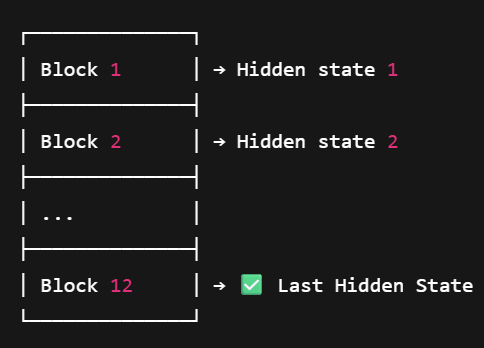

[Multi-head Attention] → [Add + Norm] → [Feedforward] → [Add + Norm]


## Example of AutoModelClass with Different heads

| Task                        | Class Name                                          | Description                                          |
| --------------------------- | --------------------------------------------------- | ---------------------------------------------------- |
| Base Model               | `AutoModel`                                         | Just embeddings (no head), for feature extraction    |
| Masked LM                | `AutoModelForMaskedLM`                              | For BERT-style `[MASK]` prediction                   |
| Sequence Classification | `AutoModelForSequenceClassification`                | For sentence-level tasks like sentiment, spam        |
| Token Classification     | `AutoModelForTokenClassification`                   | For NER, POS tagging (token-level labels)            |
| Multiple Choice          | `AutoModelForMultipleChoice`                        | For MCQ tasks (e.g., SWAG dataset)                   |
| Next Sentence Prediction | `AutoModelForNextSentencePrediction`                | For NSP (mainly BERT pretraining)                    |
| Causal LM (Text Gen)     | `AutoModelForCausalLM`                              | For GPT-style models (left-to-right text generation) |
| Seq2Seq LM               | `AutoModelForSeq2SeqLM`                             | For translation, summarization (T5, BART)            |
| Question Answering       | `AutoModelForQuestionAnswering`                     | For extractive QA (SQuAD-style)                      |
| Vision Tasks            | `AutoModelForImageClassification`, etc.             | For image classification (e.g., ViT)                 |
| Audio Tasks              | `AutoModelForAudioClassification`, etc.             | For Wav2Vec, Whisper, etc.                           |
| Conditional Generation   | `AutoModelForConditionalGeneration`                 | For T5/BART-style seq2seq tasks                      |
| Zero-shot Tasks          | `AutoModelForZeroShotClassification` (via pipeline) | For inference without fine-tuning                    |
| Contrastive Learning     | `AutoModelForContrastiveLearning`                   | For embeddings comparison tasks                      |


In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

text = "Hello, how are [MASK]?"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

mask_index = torch.where(inputs["input_ids"][0] == tokenizer.mask_token_id)[0]
predicted_id = outputs.logits[0, mask_index].argmax(dim=-1)

print(tokenizer.decode(predicted_id))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


you


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "Explain reinforcement learning in simple words."

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Explain reinforcement learning in simple words.


In [ ]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [ ]:
print(model.config)
print("Layers:", model.config.num_hidden_layers)
print("Hidden size:", model.config.hidden_size)
print("Attention heads:", model.config.num_attention_heads)
print("Vocab size:", model.config.vocab_size)

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "dtype": "bfloat16",
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 5632,
  "max_position_embeddings": 2048,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 22,
  "num_key_value_heads": 4,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": false,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 32000
}

Layers: 22
Hidden size: 2048
Attention heads: 32
Vocab size: 32000


In [ ]:
print(len(model.model.layers))

22


In [ ]:
print(model.model.layers[0].self_attn)

LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)


In [ ]:
for i, layer in enumerate(model.model.layers):
    print(f"Layer {i}")
    print(layer.self_attn)
    print("-" * 50)

Layer 0
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
--------------------------------------------------
Layer 1
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
--------------------------------------------------
Layer 2
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
----------

In [ ]:
text = "Hello, how are you?"
inputs = tokenizer(text, return_tensors="pt")

print(inputs)
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

{'input_ids': tensor([[    1, 15043, 29892,   920,   526,   366, 29973]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
['<s>', '▁Hello', ',', '▁how', '▁are', '▁you', '?']


In [ ]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.keys())

odict_keys(['logits', 'past_key_values'])


[batch_size, sequence_length, vocab_size]

In [ ]:
print(outputs.logits.shape)

torch.Size([1, 7, 32000])


In [ ]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))

Hello, how are you?

Jane:
(smiling)
I'm doing well, thank you.

Tom:
(smiling back)
Me too. How about you?

Jane:
(laughing)
I


In [ ]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

print(len(outputs.hidden_states))
print(outputs.hidden_states[-1].shape)

23
torch.Size([1, 7, 2048])


local_dir_use_symlinks=True
→ Creates shortcuts that point to the original files.

local_dir_use_symlinks=False
→ Copies the actual files into the target folder.

In [ ]:
from huggingface_hub import snapshot_download

In [ ]:
snapshot_download(
    repo_id="bert-base-uncased",
    local_dir="/content/test",   # where to download
    local_dir_use_symlinks=False  # to copy instead of symlinking
)

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("/content/test")

In [ ]:
tokenizer

In [ ]:
model = AutoModel.from_pretrained("/content/test")

In [ ]:
model

In [ ]:
!pip install -U sentence-transformers

In [ ]:
sentence1="I love AI"
sentence2="I love car"

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embedding1 = model.encode(sentence1, convert_to_tensor=True)

In [ ]:
embedding1

tensor([-4.6540e-02, -5.8470e-02,  4.0854e-02, -4.4258e-02,  6.4161e-02,
        -2.8447e-02,  9.0418e-02,  2.8513e-02,  6.6804e-02,  2.4606e-02,
        -8.0397e-02, -3.5051e-02,  7.8801e-03,  9.3046e-03, -1.1161e-02,
         3.7696e-02, -1.5667e-02, -1.7484e-02, -1.1090e-01, -7.7187e-02,
        -1.1623e-01,  2.8937e-02,  2.8869e-02, -2.8547e-02, -1.9943e-02,
         7.7708e-02,  1.8509e-02, -8.7126e-02,  1.4317e-02, -8.9478e-02,
         1.1828e-02,  1.1094e-02,  9.1560e-02,  8.7174e-03, -1.0687e-01,
         3.1963e-02, -2.9026e-02, -3.2826e-02,  4.0608e-02, -1.6036e-02,
        -1.9270e-02, -1.7278e-02,  4.4056e-02, -6.3018e-02,  3.9768e-02,
         4.7682e-02, -4.8478e-02, -2.8900e-02,  1.2391e-01,  8.4188e-02,
        -6.3641e-02, -2.8401e-02,  1.2736e-03, -1.1502e-02,  1.8941e-02,
         3.1359e-02,  4.0939e-02,  3.6522e-03, -2.0747e-02, -3.7307e-02,
         6.3742e-02,  1.1975e-02,  5.1552e-02, -9.6216e-04,  5.8577e-02,
         2.7640e-02,  7.5896e-03, -1.2847e-02, -3.6

In [ ]:
len(embedding1)

384

In [ ]:
embedding2 = model.encode(sentence2, convert_to_tensor=True)

In [ ]:
embedding2

tensor([-3.8801e-02,  4.5633e-02,  7.8054e-02, -2.1323e-02, -4.4257e-03,
         1.0737e-02,  9.9434e-02,  5.6415e-02,  4.8730e-02,  3.3117e-02,
        -2.4869e-02,  1.1764e-02,  3.3558e-03,  2.7329e-02, -3.4777e-04,
        -2.3869e-02,  1.3444e-02, -9.8259e-03, -6.8073e-02,  4.0447e-03,
        -1.3739e-01,  4.4341e-02,  1.1902e-02,  2.2283e-02, -8.3516e-02,
         6.9258e-02, -7.2918e-04,  3.6496e-02, -1.1259e-02, -6.1629e-02,
        -1.4503e-02,  7.5621e-02,  8.4547e-03, -3.0975e-03, -2.2890e-02,
        -7.6427e-02,  2.3704e-02, -4.6675e-02, -2.5668e-03, -1.2273e-02,
        -3.2564e-02, -1.8593e-02,  2.1801e-02, -1.1610e-02,  1.0503e-04,
        -3.5133e-02,  5.5307e-02, -3.6497e-03,  1.4518e-01, -5.6403e-02,
         4.5454e-02,  1.8224e-02, -2.6752e-02, -4.5586e-02, -5.8457e-02,
         2.7006e-02, -2.1611e-05,  5.0962e-02, -2.7013e-02, -2.1655e-02,
         1.0141e-01,  2.2524e-02, -2.6393e-03, -1.2814e-02,  3.4960e-03,
        -1.3059e-02,  5.8906e-03, -9.5167e-03, -1.8

In [ ]:
## unsqueeze(0) converts a single embedding vector [768] into a one-sample batch [1, 768].

In [ ]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    embedding1.unsqueeze(0),
    embedding2.unsqueeze(0)
)

print(similarity.item())

0.46875208616256714
